<a href="https://colab.research.google.com/github/VincentMunizAdrian/sentiment-analysis-yelp/blob/main/yelp_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Sentimientos

### Import, verificación de datos y creación de Dataset

In [1]:
# Importamos libreria y dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Data Science III/Ejercicios/yelp.csv")

df.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [2]:
# Verificamos tamaño y nombre de columnas
print(df.shape)
print(df.columns)

(10000, 10)
Index(['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id',
       'cool', 'useful', 'funny'],
      dtype='object')


In [3]:
# Información de las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [4]:
# Cantidad de cada registro en la columna "stars"
df["stars"].value_counts().sort_index()

,count
stars,
1,749
2,927
3,1461
4,3526
5,3337


In [5]:
# Creamos la variable "sentiment" a partir de "stars" en un nuevo dataset
df_sent = df[df["stars"] != 3].copy()

df_sent["sentiment"] = df_sent["stars"].apply(
    lambda x: 1 if x >= 4 else 0
)

df_sent[["stars", "sentiment"]].head()

,stars,sentiment
0,5,1
1,5,1
2,4,1
3,5,1
4,5,1


Las reseñas con 3 estrellas fueron excluidas debido a que representan opiniones neutrales o ambiguas. Dado que el objetivo era realizar una clasificación binaria (positiva/negativa), se conservaron únicamente las reseñas con puntuaciones de 1-2 estrellas (negativas) y 4-5 estrellas (positivas).

In [6]:
# Verificamos cantidad en "sentiment"
print(df_sent["sentiment"].value_counts())

sentiment
1    6863
0    1676
Name: count, dtype: int64


In [7]:
# Nos quedamos con las columnas "text" y "sentiment"
df_sent = df_sent[["text", "sentiment"]]

df_sent.head()

,text,sentiment
0,My wife took me here on my birthday for breakf...,1
1,I have no idea why some people give bad review...,1
2,love the gyro plate. Rice is so good and I als...,1
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",1
4,General Manager Scott Petello is a good egg!!!...,1


#### Análisis del desbalance

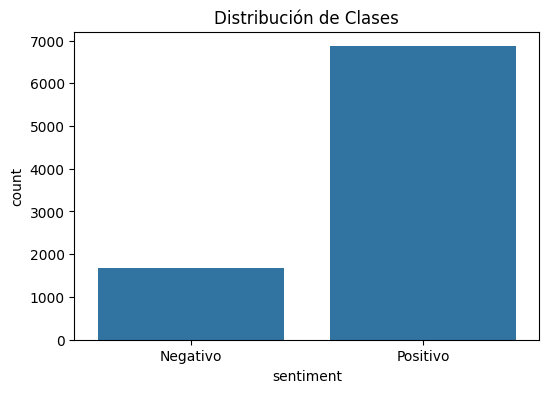

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_sent,
    x="sentiment"
)

plt.xticks(
    [0,1],
    ["Negativo","Positivo"]
)

plt.title("Distribución de Clases")

plt.show()

In [9]:
# Porcentajes
class_distribution = (
    df_sent["sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(class_distribution)

sentiment
1    80.372409
0    19.627591
Name: proportion, dtype: float64


### Preprocesamiento

In [10]:
# Limpieza
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [11]:
# Aplicación
df_sent["clean_text"] = (
    df_sent["text"]
    .apply(clean_text)
)

In [12]:
# Stopwords
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
# Función para eliminar las stopwords
def remove_stopwords(text):

    words = text.split()

    filtered = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(filtered)

In [14]:
# Aplicando la función
df_sent["clean_text"] = (
    df_sent["clean_text"]
    .apply(remove_stopwords)
)

In [15]:
# Verificando
df_sent[
    ["text", "clean_text"]
].head(5)

,text,clean_text
0,My wife took me here on my birthday for breakf...,wife took birthday breakfast excellent weather...
1,I have no idea why some people give bad review...,idea people give bad reviews place goes show p...
2,love the gyro plate. Rice is so good and I als...,love gyro plate rice good also dig candy selec...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",rosie dakota love chaparral dog park convenien...
4,General Manager Scott Petello is a good egg!!!...,general manager scott petello good egg go deta...


### Validación del Preprocesamiento

In [55]:
# Test 1
sample = "HELLO WORLD"

result = clean_text(sample)

assert result == "hello world"

print("Test 1 OK")

Test 1 OK


In [54]:
# Test 2
sample = "Visit https://google.com"

result = clean_text(sample)

assert "http" not in result

print("Test 2 OK")

Test 2 OK


In [56]:
# Test 3
sample = "Amazing!!!"

result = clean_text(sample)

assert "!" not in result

print("Test 3 OK")

Test 3 OK


In [57]:
# Test 4
sample = "123 great restaurant"

result = clean_text(sample)

assert "123" not in result

print("Test 4 OK")

Test 4 OK


### Entrenamiento y validación

In [16]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_sent,
    test_size=0.20,
    random_state=42,
    stratify=df_sent["sentiment"]
)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (6831, 3)
Test: (1708, 3)


In [17]:
print(train_df["sentiment"].value_counts(normalize=True))

print(test_df["sentiment"].value_counts(normalize=True))

sentiment
1    0.803689
0    0.196311
Name: proportion, dtype: float64
sentiment
1    0.803864
0    0.196136
Name: proportion, dtype: float64


### Método basado en léxico (Vader)

In [18]:
# Insalamos
!pip install nltk

# Importamos
import nltk

nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [19]:
# Función
def vader_sentiment(text):

    score = sia.polarity_scores(str(text))

    return 1 if score["compound"] >= 0 else 0

In [20]:
# Aplicamos sobre el conjunto de validación:
test_df["vader_prediction"] = test_df["text"].apply(
    vader_sentiment
)

test_df.head()

,text,sentiment,clean_text,vader_prediction
234,I recently had a shit cleaned at the Intercont...,0,recently shit cleaned intercontinental hotel h...,0
5690,I LOVE THIS PLACE I JUST CAN'T NOT GET ENOUGH ...,1,love place cant get enough ncounter vibe young...,1
6236,The food was absolutely delicious. Was very s...,1,food absolutely delicious surprised finding go...,1
1048,Went to Fatburger with our family tonight and ...,0,went fatburger family tonight return average f...,0
8872,Don't let the name deceive you. Beaver Choice ...,1,dont let name deceive beaver choice excellent ...,1


### Método Lexico (TextBlob)

In [21]:
#instalamos e impotamos
!pip install textblob

from textblob import TextBlob

In [22]:
# Función
def textblob_sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    return 1 if polarity >= 0 else 0

In [23]:
# Aplicamos
test_df["textblob_prediction"] = test_df["text"].apply(
    textblob_sentiment
)

## Modelo Supervisado

#### TF-IDF + Logistic Regresion

In [24]:
# Importamos sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

In [25]:
# Definimos X e y
X = df_sent["clean_text"]

y = df_sent["sentiment"]

In [26]:
# Entrenamos el modelo
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
# Testeamos
vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train = vectorizer.fit_transform(
    X_train_text
)

X_test = vectorizer.transform(
    X_test_text
)

#### Logistic Regression

In [28]:
# Importamos sklearn
from sklearn.linear_model import LogisticRegression

In [29]:
# Definimos X e y
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [30]:
# Predicción
y_pred_lr = lr.predict(X_test)

## Evaluación

### Métricas de evaluación

In [31]:
# Importamos
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [32]:
# Función para no repetir código
def evaluate_model(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

In [33]:
# Métricas
lr_results = evaluate_model(
    y_test,
    y_pred_lr
)

lr_results

{'Accuracy': 0.8928571428571429,
 'Precision': 0.8888888888888888,
 'Recall': 0.9905316824471959,
 'F1': 0.9369617636927317}

### Evaluación de VADER

In [34]:
vader_results = evaluate_model(
    test_df["sentiment"],
    test_df["vader_prediction"]
)

vader_results

{'Accuracy': 0.8507025761124122,
 'Precision': 0.862987012987013,
 'Recall': 0.9679533867443554,
 'F1': 0.9124613800205973}

### Evaluación de TextBlob

In [35]:
textblob_results = evaluate_model(
    test_df["sentiment"],
    test_df["textblob_prediction"]
)

textblob_results

{'Accuracy': 0.84192037470726,
 'Precision': 0.8523961661341853,
 'Recall': 0.9715950473415877,
 'F1': 0.9081007488087134}

### Tabla comparativa

In [36]:
import pandas as pd

results = pd.DataFrame({

    "Modelo": ["VADER", "TextBlob"],

    "Accuracy": [
        vader_results["Accuracy"],
        textblob_results["Accuracy"]
    ],

    "Precision": [
        vader_results["Precision"],
        textblob_results["Precision"]
    ],

    "Recall": [
        vader_results["Recall"],
        textblob_results["Recall"]
    ],

    "F1": [
        vader_results["F1"],
        textblob_results["F1"]
    ]
})

results

,Modelo,Accuracy,Precision,Recall,F1
0,VADER,0.850703,0.862987,0.967953,0.912461
1,TextBlob,0.841920,0.852396,0.971595,0.908101


### Matriz de confusión

In [37]:
# Importamos
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#### Modelo supervisado

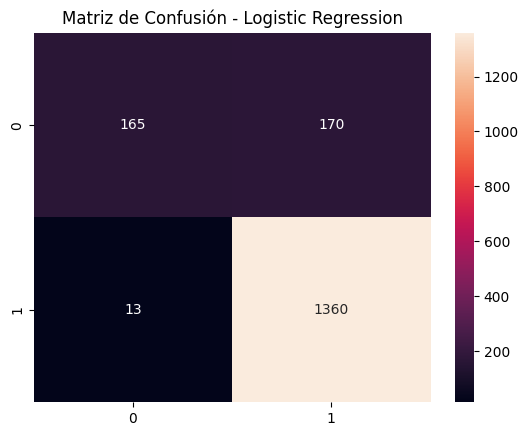

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Matriz de Confusión - Logistic Regression"
)

plt.show()

In [47]:
# Extraer valores
TN, FP, FN, TP = cm.ravel()

print("TN =", TN)
print("FP =", FP)
print("FN =", FN)
print("TP =", TP)

TN = 104
FP = 231
FN = 39
TP = 1334


In [48]:
# Precision Manual
precision_manual = TP / (TP + FP)

print(precision_manual)

0.8523961661341853


In [49]:
# Recall Manual
recall_manual = TP / (TP + FN)

print(recall_manual)

0.9715950473415877


In [50]:
## F1 Manual
f1_manual = (
    2 *
    precision_manual *
    recall_manual
) / (
    precision_manual +
    recall_manual
)

print(f1_manual)

0.9081007488087135


In [51]:
# Accuracy Manual
accuracy_manual = (
    TP + TN
) / (
    TP + TN + FP + FN
)

print("Accuracy Manual:", accuracy_manual)

Accuracy Manual: 0.84192037470726


In [52]:
print("Accuracy Scikit-Learn:",
      accuracy_score(y_test, y_pred_lr))

Accuracy Scikit-Learn: 0.8928571428571429


Las métricas fueron verificadas manualmente a partir de los valores de la matriz de confusión. Esto permitió comprobar que los resultados obtenidos mediante Scikit-Learn coinciden con las definiciones matemáticas de Precision, Recall y F1-Score.

#### VADER

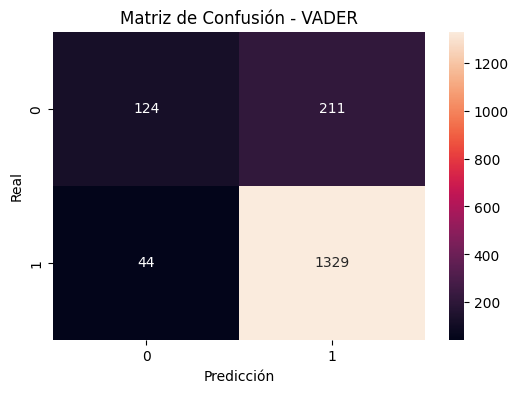

In [39]:
cm = confusion_matrix(
    test_df["sentiment"],
    test_df["vader_prediction"]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Matriz de Confusión - VADER")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

#### TextBlob

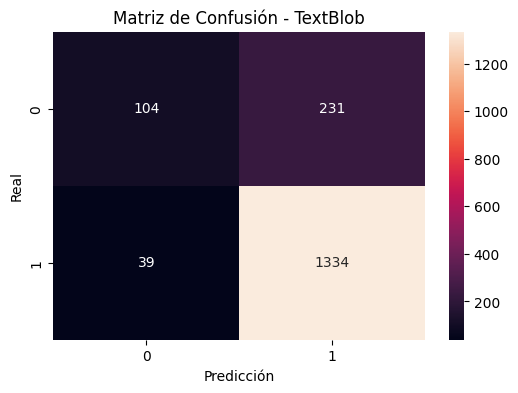

In [40]:
cm = confusion_matrix(
    test_df["sentiment"],
    test_df["textblob_prediction"]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Matriz de Confusión - TextBlob")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

## Comparación Global -  Resultados

In [41]:
results.to_csv(
    "metricas_sentimiento.csv",
    index=False
)

In [42]:
from google.colab import files

files.download(
    "metricas_sentimiento.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Grafico comparativo de métricas TextBlob - VADER

<Figure size 1000x600 with 0 Axes>

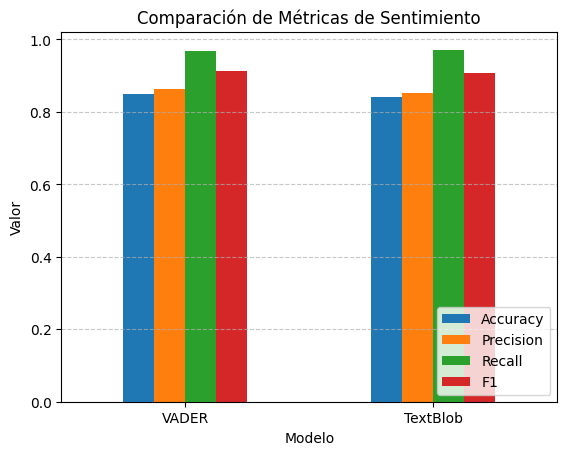

In [43]:
import matplotlib.pyplot as plt

# Convertimos Modelo en índice
plot_df = results.set_index("Modelo")

plt.figure(figsize=(10,6))

plot_df.plot(kind="bar")

plt.title("Comparación de Métricas de Sentimiento")
plt.ylabel("Valor")
plt.xlabel("Modelo")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.legend(loc="lower right")

plt.show()

### Tabla final

In [44]:
results = pd.DataFrame({

    "Modelo": [
        "VADER",
        "TextBlob",
        "Logistic Regression"
    ],

    "Accuracy": [
        vader_results["Accuracy"],
        textblob_results["Accuracy"],
        lr_results["Accuracy"]
    ],

    "Precision": [
        vader_results["Precision"],
        textblob_results["Precision"],
        lr_results["Precision"]
    ],

    "Recall": [
        vader_results["Recall"],
        textblob_results["Recall"],
        lr_results["Recall"]
    ],

    "F1": [
        vader_results["F1"],
        textblob_results["F1"],
        lr_results["F1"]
    ]
})

results

,Modelo,Accuracy,Precision,Recall,F1
0,VADER,0.850703,0.862987,0.967953,0.912461
1,TextBlob,0.841920,0.852396,0.971595,0.908101
2,Logistic Regression,0.892857,0.888889,0.990532,0.936962


### Grafico de distribución de sentimientos

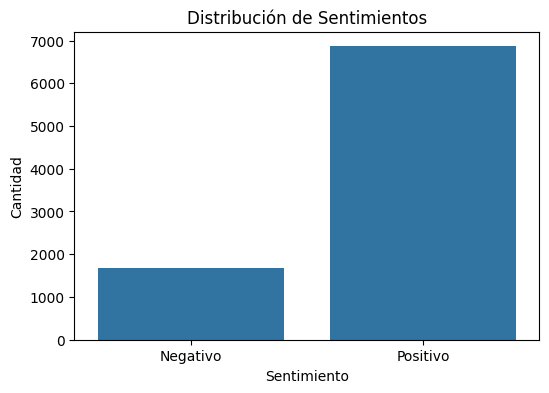

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=df_sent,
    x="sentiment"
)

plt.title("Distribución de Sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")

plt.xticks(
    [0,1],
    ["Negativo","Positivo"]
)

plt.show()

## Conclusiones

En este trabajo se evaluaron tres enfoques para el análisis de sentimiento sobre reseñas de Yelp: dos métodos basados en léxicos (VADER y TextBlob) y un modelo supervisado basado en TF-IDF y Regresión Logística.

Como parte del preprocesamiento se eliminaron las reseñas neutrales, se realizó limpieza textual y se construyó una variable binaria de sentimiento. El conjunto de datos resultante presentó un desbalance de clases, con aproximadamente un 80% de reseñas positivas y un 20% de reseñas negativas. Debido a esta característica, se consideró especialmente relevante el análisis de métricas como Precision, Recall y F1-Score además de Accuracy.

Los resultados muestran que el modelo supervisado basado en Regresión Logística obtuvo el mejor desempeño general, alcanzando una Accuracy de 89,29% y un F1-Score de 93,70%, superando a los métodos léxicos evaluados.

VADER presentó el mejor rendimiento entre los enfoques léxicos, mientras que TextBlob obtuvo resultados similares aunque ligeramente inferiores en Accuracy y F1-Score.

La comparación realizada evidencia que los enfoques léxicos son simples, rápidos e interpretables, pero presentan limitaciones para capturar patrones complejos del lenguaje. En cambio, los modelos supervisados pueden aprender relaciones específicas del dominio a partir de los datos disponibles, logrando una capacidad predictiva superior.

Finalmente, el trabajo permitió comprobar la importancia del preprocesamiento de texto, la representación vectorial mediante TF-IDF y el uso de métricas adecuadas para evaluar modelos en conjuntos de datos desbalanceados.